In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#### Импортируем данные

In [2]:
DIR = './data/'

train = pd.read_csv(DIR + 'train.csv')
test = pd.read_csv(DIR + 'test.csv')
gender_sub = pd.read_csv(DIR + 'gender_submission.csv') # пример загрузки на кеглю

#### Первичный анализ

In [3]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
train.shape

(891, 12)

In [5]:
train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
train.describe(include=['O']) # для категориальных признаков

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,B96 B98,S
freq,1,577,7,4,644


In [7]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


#### Удаление ненужного столбца PassengerId

In [8]:
train = train.drop(columns=['PassengerId'], axis=1)
train.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


#### Проверка пустых значений

In [9]:
train.isnull().sum()

Survived      0
Pclass        0
Name          0
Sex           0
Age         177
SibSp         0
Parch         0
Ticket        0
Fare          0
Cabin       687
Embarked      2
dtype: int64

#### Проверка возраста

In [10]:
train['Age'].value_counts()

24.00    30
22.00    27
18.00    26
19.00    25
28.00    25
         ..
36.50     1
55.50     1
0.92      1
23.50     1
74.00     1
Name: Age, Length: 88, dtype: int64

In [11]:
mean_age = train['Age'].mean()
std_age = train['Age'].std()
size_age_null_train = train['Age'].isnull().sum()
size_age_null_test = test['Age'].isnull().sum()
random_age_train = np.random.randint(mean_age - std_age, mean_age + std_age, size=size_age_null_train)
random_age_test = np.random.randint(mean_age - std_age, mean_age + std_age, size=size_age_null_test)

In [12]:
train['Age'][np.isnan(train['Age'])] = random_age_train

C:\Users\zekat\AppData\Local\Temp\ipykernel_16872\3389494526.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train['Age'][np.isnan(train['Age'])] = random_age_train


In [13]:
###  for test
test['Age'][np.isnan(test['Age'])] = random_age_test

C:\Users\zekat\AppData\Local\Temp\ipykernel_16872\2475252296.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['Age'][np.isnan(test['Age'])] = random_age_test


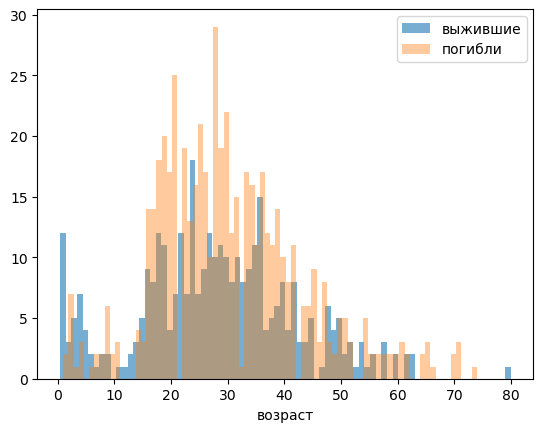

In [14]:
plt.hist(train[train['Survived'] == 1]['Age'].values, bins=80, label='выжившие', alpha=0.6)
plt.hist(train[train['Survived'] == 0]['Age'].values, bins=80, label='погибли', alpha=0.4)
plt.legend(loc='best')
plt.xlabel('возраст')
plt.show()

#### Проверка номера каюты

In [15]:
train.Cabin.value_counts()

B96 B98        4
G6             4
C23 C25 C27    4
C22 C26        3
F33            3
              ..
E34            1
C7             1
C54            1
E36            1
C148           1
Name: Cabin, Length: 147, dtype: int64

In [16]:
from collections import Counter
Counter(train['Cabin'].values).most_common()

[(nan, 687),
 ('G6', 4),
 ('C23 C25 C27', 4),
 ('B96 B98', 4),
 ('F33', 3),
 ('E101', 3),
 ('F2', 3),
 ('D', 3),
 ('C22 C26', 3),
 ('C123', 2),
 ('D33', 2),
 ('C52', 2),
 ('B28', 2),
 ('C83', 2),
 ('F G73', 2),
 ('D26', 2),
 ('B58 B60', 2),
 ('C2', 2),
 ('E33', 2),
 ('F4', 2),
 ('D36', 2),
 ('C93', 2),
 ('C78', 2),
 ('D35', 2),
 ('B77', 2),
 ('E67', 2),
 ('C125', 2),
 ('B49', 2),
 ('C65', 2),
 ('B57 B59 B63 B66', 2),
 ('B18', 2),
 ('C124', 2),
 ('B35', 2),
 ('E44', 2),
 ('C92', 2),
 ('D20', 2),
 ('E25', 2),
 ('B22', 2),
 ('C68', 2),
 ('C126', 2),
 ('B51 B53 B55', 2),
 ('B5', 2),
 ('B20', 2),
 ('E24', 2),
 ('E8', 2),
 ('E121', 2),
 ('D17', 2),
 ('C85', 1),
 ('E46', 1),
 ('C103', 1),
 ('D56', 1),
 ('A6', 1),
 ('B78', 1),
 ('B30', 1),
 ('E31', 1),
 ('A5', 1),
 ('D10 D12', 1),
 ('C110', 1),
 ('F E69', 1),
 ('D47', 1),
 ('B86', 1),
 ('B19', 1),
 ('A7', 1),
 ('C49', 1),
 ('A32', 1),
 ('B4', 1),
 ('B80', 1),
 ('A31', 1),
 ('D15', 1),
 ('C87', 1),
 ('B94', 1),
 ('C99', 1),
 ('C118', 1),
 ('D7'

In [17]:
train = train.drop(columns='Cabin', axis=1)
train.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [18]:
### for test
test = test.drop(columns='Cabin', axis=1)

#### Удаление строк Embarked, где есть NaN

In [19]:
train = train.dropna(axis=0)
train

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S
...,...,...,...,...,...,...,...,...,...,...
886,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S
887,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S
888,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,21.0,1,2,W./C. 6607,23.4500,S
889,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C


#### Изменение фич Name

In [20]:
train['Name'] = train.Name.str.extract('([A-Za-z]+)\.')

In [21]:
### for test
test['Name'] = test.Name.str.extract('([A-Za-z]+)\.')

In [22]:
train.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,0,3,Mr,male,22.0,1,0,A/5 21171,7.2500,S
1,1,1,Mrs,female,38.0,1,0,PC 17599,71.2833,C
2,1,3,Miss,female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,1,1,Mrs,female,35.0,1,0,113803,53.1000,S
4,0,3,Mr,male,35.0,0,0,373450,8.0500,S


In [23]:
pd.crosstab(train['Name'], train['Sex'])

Sex,female,male
Name,,
Capt,0,1
Col,0,2
Countess,1,0
Don,0,1
Dr,1,6
Jonkheer,0,1
Lady,1,0
Major,0,2
Master,0,40


In [24]:
train.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,0,3,Mr,male,22.0,1,0,A/5 21171,7.2500,S
1,1,1,Mrs,female,38.0,1,0,PC 17599,71.2833,C
2,1,3,Miss,female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,1,1,Mrs,female,35.0,1,0,113803,53.1000,S
4,0,3,Mr,male,35.0,0,0,373450,8.0500,S


Теперь заменим некоторые не столь широко используемые Обращения значением "Other".

In [25]:
for data in [train, test]:
    data['Name'] = data['Name'].replace(['Lady', 'Countess','Capt', 'Col', \
                                                     'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Other')

    data['Name'] = data['Name'].replace('Mlle', 'Miss')
    data['Name'] = data['Name'].replace('Ms', 'Miss')
    data['Name'] = data['Name'].replace('Mme', 'Mrs')

In [26]:
train[['Name', 'Survived']].groupby(['Name'], as_index=False).mean()

,Name,Survived
0,Master,0.575000
1,Miss,0.701087
2,Mr,0.156673
3,Mrs,0.792000
4,Other,0.347826


In [27]:
train['Name'].unique()

array(['Mr', 'Mrs', 'Miss', 'Master', 'Other'], dtype=object)

Удаление столбца Ticket

In [28]:
train = train.drop(columns='Ticket', axis=1)
test = test.drop(columns='Ticket', axis=1)

In [29]:
train.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,Mr,male,22.0,1,0,7.2500,S
1,1,1,Mrs,female,38.0,1,0,71.2833,C
2,1,3,Miss,female,26.0,0,0,7.9250,S
3,1,1,Mrs,female,35.0,1,0,53.1000,S
4,0,3,Mr,male,35.0,0,0,8.0500,S


Удаление строк Fare, где есть 0

In [30]:
test.isnull().sum()

PassengerId    0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Fare           1
Embarked       0
dtype: int64

In [31]:
test = test.fillna(test.mean())

C:\Users\zekat\AppData\Local\Temp\ipykernel_16872\789818481.py:1: FutureWarning: Dropping of nuisance columns in DataFrame reductions (with 'numeric_only=None') is deprecated; in a future version this will raise TypeError.  Select only valid columns before calling the reduction.
  test = test.fillna(test.mean())


In [32]:
test.isnull().sum()

PassengerId    0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Fare           0
Embarked       0
dtype: int64

#### One-Hot-Encoding

In [33]:
train.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,Mr,male,22.0,1,0,7.2500,S
1,1,1,Mrs,female,38.0,1,0,71.2833,C
2,1,3,Miss,female,26.0,0,0,7.9250,S
3,1,1,Mrs,female,35.0,1,0,53.1000,S
4,0,3,Mr,male,35.0,0,0,8.0500,S


In [34]:
sex_dummies = pd.get_dummies(train.Sex, drop_first=True, prefix='Sex')
train = pd.concat([train, sex_dummies], axis=1)
train = train.drop(columns='Sex', axis=1)

embarked_dummies = pd.get_dummies(train.Embarked, drop_first=True, prefix='Embarked')
train = pd.concat([train, embarked_dummies], axis=1)
train = train.drop(columns='Embarked', axis=1)

name_dummies = pd.get_dummies(train.Name, drop_first=True, prefix='Name')
train_name = pd.concat([train, name_dummies], axis=1)
train_name = train_name.drop(columns='Name', axis=1)

In [35]:
sex_dummies = pd.get_dummies(test.Sex, drop_first=True, prefix='Sex')
test = pd.concat([test, sex_dummies], axis=1)
test = test.drop(columns='Sex', axis=1)

embarked_dummies = pd.get_dummies(test.Embarked, drop_first=True, prefix='Embarked')
test = pd.concat([test, embarked_dummies], axis=1)
test = test.drop(columns='Embarked', axis=1)

name_dummies = pd.get_dummies(test.Name, drop_first=True, prefix='Name')
test_name = pd.concat([test, name_dummies], axis=1)
test_name = test_name.drop(columns='Name', axis=1)

In [36]:
# for data in [train, test]:
#     name_dummies = pd.get_dummies(data.Name, drop_first=True, prefix='Name')
#     data = pd.concat([data, name_dummies], axis=1)
#     data = data.drop(columns='Name', axis=1)

#     sex_dummies = pd.get_dummies(data.Sex, drop_first=True, prefix='Sex')
#     data = pd.concat([data, sex_dummies], axis=1)
#     data = data.drop(columns='Sex', axis=1)

#     embarked_dummies = pd.get_dummies(data.Embarked, drop_first=True, prefix='Embarked')
#     data = pd.concat([data, embarked_dummies], axis=1)
#     data = data.drop(columns='Embarked', axis=1)

#     name_noise_dummies = pd.get_dummies(data.Name_noise, drop_first=True, prefix='Name_noise')
#     data = pd.concat([data, name_noise_dummies], axis=1)
#     data = data.drop(columns='Name_noise', axis=1)

In [37]:
print(train_name.shape, test_name.shape)

(889, 13) (418, 13)


#### Scaling (масштабирование признаков)

Будем использовать стандартизацию [-1, 1]

In [38]:
train_name.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S,Name_Miss,Name_Mr,Name_Mrs,Name_Other
0,0,3,22.0,1,0,7.2500,1,0,1,0,1,0,0
1,1,1,38.0,1,0,71.2833,0,0,0,0,0,1,0
2,1,3,26.0,0,0,7.9250,0,0,1,1,0,0,0
3,1,1,35.0,1,0,53.1000,0,0,1,0,0,1,0
4,0,3,35.0,0,0,8.0500,1,0,1,0,1,0,0


In [39]:
from sklearn.preprocessing import StandardScaler

scs = StandardScaler()

In [40]:
train_name[['Age', 'Fare', 'SibSp', 'Parch']] = scs.fit_transform(train_name[['Age', 'Fare', 'SibSp', 'Parch']])

In [41]:
train_name.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S,Name_Miss,Name_Mr,Name_Mrs,Name_Other
count,889.000000,889.000000,8.890000e+02,8.890000e+02,8.890000e+02,8.890000e+02,889.000000,889.000000,889.000000,889.000000,889.000000,889.000000,889.000000
mean,0.382452,2.311586,2.381235e-16,6.668831e-17,1.198891e-17,1.092115e-16,0.649044,0.086614,0.724409,0.206974,0.581552,0.140607,0.025872
std,0.486260,0.834700,1.000563e+00,1.000563e+00,1.000563e+00,1.000563e+00,0.477538,0.281427,0.447063,0.405365,0.493582,0.347812,0.158842
min,0.000000,1.000000,-2.168965e+00,-4.751991e-01,-4.743259e-01,-6.462044e-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,-6.373988e-01,-4.751991e-01,-4.743259e-01,-4.872378e-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,3.000000,-1.164579e-01,-4.751991e-01,-4.743259e-01,-3.551972e-01,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000
75%,1.000000,3.000000,5.533233e-01,4.313502e-01,-4.743259e-01,-2.207954e-02,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000
max,1.000000,3.000000,3.753389e+00,6.777195e+00,6.967010e+00,9.668551e+00,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [42]:
test_name[['Age', 'Fare', 'SibSp', 'Parch']] = scs.fit_transform(test_name[['Age', 'Fare', 'SibSp', 'Parch']])

#### Моделирование

In [43]:
train_name.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S,Name_Miss,Name_Mr,Name_Mrs,Name_Other
0,0,3,-0.562979,0.431350,-0.474326,-0.500240,1,0,1,0,1,0,0
1,1,1,0.627743,0.431350,-0.474326,0.788947,0,0,0,0,0,1,0
2,1,3,-0.265298,-0.475199,-0.474326,-0.486650,0,0,1,1,0,0,0
3,1,1,0.404483,0.431350,-0.474326,0.422861,0,0,1,0,0,1,0
4,0,3,0.404483,-0.475199,-0.474326,-0.484133,1,0,1,0,1,0,0


In [44]:
test_name.head()

,PassengerId,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S,Name_Miss,Name_Mr,Name_Mrs,Name_Other
0,892,3,0.337851,-0.499470,-0.400248,-0.498407,1,1,0,0,1,0,0
1,893,3,1.292825,0.616992,-0.400248,-0.513274,0,0,1,0,0,1,0
2,894,2,2.438794,-0.499470,-0.400248,-0.465088,1,1,0,0,1,0,0
3,895,3,-0.235134,-0.499470,-0.400248,-0.483466,1,0,1,0,1,0,0
4,896,3,-0.617124,0.616992,0.619896,-0.418471,0,0,1,0,0,1,0


In [45]:
X_train = train_name.drop(columns='Survived', axis=1).values
y_train = train_name['Survived'].values

X_test = test_name.drop(columns='PassengerId', axis=1).copy()

In [46]:
X_train.shape, y_train.shape, X_test.shape

((889, 12), (889,), (418, 12))

Логистическая регрессия с методом опорных векторов

In [47]:
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline

pipe_lr = make_pipeline(PCA(n_components=4),
                        LogisticRegression(random_state=1,
                                           solver='lbfgs'))

pipe_lr.fit(X_train, y_train)
print('acc: ', pipe_lr.score(X_train, y_train))

acc:  0.7570303712035995


In [48]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(estimator=pipe_lr,
                         X=X_train,
                         y=y_train,
                         cv=10,
                         n_jobs=1)
print('Меры точности перекрестной проверки: ', scores)
print('Точность перекрестной проверки: ', np.mean(scores), '+-',
      np.std(scores))

Меры точности перекрестной проверки:  [0.73033708 0.70786517 0.73033708 0.75280899 0.78651685 0.73033708
 0.76404494 0.71910112 0.79775281 0.76136364]
Точность перекрестной проверки:  0.7480464759959142 +- 0.02792831526682213


Логистическая регрессия для всех признаков

In [49]:
lr = LogisticRegression(random_state=1)
lr.fit(X_train, y_train)
print('acc: ', lr.score(X_train, y_train))

acc:  0.8267716535433071


Grid search для метода опорных векторов (SVC)

In [50]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

svc = SVC(random_state=1)

param_range = [0.01, 0.1, 1.0]
param_grid = [{'C': param_range,
               'kernel': ['linear']},
              {'C': param_range,
               'gamma': param_range,
               'kernel': ['rbf']}]

gs = GridSearchCV(estimator=svc,
                  param_grid=param_grid,
                  scoring='accuracy',
                  cv=10, refit=True, n_jobs=-1)
gs.fit(X_train, y_train)
print(gs.best_score_)
print(gs.best_params_)

0.8301710929519917
{'C': 1.0, 'gamma': 0.1, 'kernel': 'rbf'}


Градиентный бустинг

In [51]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(n_estimators=300, max_depth=1)
gb = gb.fit(X_train, y_train)
gb.score(X_train, y_train)

0.829021372328459

Бэггинг

In [52]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(criterion='entropy',
                              random_state=1,
                              max_depth=None)
bag = BaggingClassifier(base_estimator=tree,
                        n_estimators=100,
                        max_samples=1.0,
                        max_features=1.0,
                        bootstrap=True,
                        bootstrap_features=False,
                        n_jobs=1,
                        random_state=1)
bag = bag.fit(X_train, y_train)
bag.score(X_train, y_train)

0.984251968503937

AdaBoost

In [53]:
from sklearn.ensemble import AdaBoostClassifier
tree = DecisionTreeClassifier(criterion='entropy',
                              random_state=1,
                              max_depth=1)

ada = AdaBoostClassifier(base_estimator=tree,
                         n_estimators=500,
                         learning_rate=0.1,
                         random_state=1)
ada = ada.fit(X_train, y_train)
ada.score(X_train, y_train)

0.8267716535433071

Catboost

In [54]:
from catboost import CatBoostClassifier

cat = CatBoostClassifier(random_state=1)
cat.fit(X_train,y_train, verbose=False, plot=True)
cat.score(X_train,y_train)

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

0.8998875140607424

In [55]:
cat = CatBoostClassifier(random_state=1)
grid = {'learning_rate': [0.03, 0.1],
        'depth': [4, 6, 10],
        'l2_leaf_reg': [1, 3, 5, 7, 9]}

grid_search_result = cat.grid_search(grid, X=X_train, y=y_train, plot=True)

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

0:	learn: 0.6761621	test: 0.6775143	best: 0.6775143 (0)	total: 884us	remaining: 884ms
1:	learn: 0.6588534	test: 0.6606798	best: 0.6606798 (1)	total: 1.72ms	remaining: 859ms
2:	learn: 0.6437988	test: 0.6453821	best: 0.6453821 (2)	total: 2.43ms	remaining: 808ms
3:	learn: 0.6288482	test: 0.6303073	best: 0.6303073 (3)	total: 3.17ms	remaining: 788ms
4:	learn: 0.6174219	test: 0.6202399	best: 0.6202399 (4)	total: 3.91ms	remaining: 778ms
5:	learn: 0.6051967	test: 0.6077799	best: 0.6077799 (5)	total: 4.61ms	remaining: 763ms
6:	learn: 0.5979730	test: 0.6002190	best: 0.6002190 (6)	total: 5.08ms	remaining: 721ms
7:	learn: 0.5872098	test: 0.5891692	best: 0.5891692 (7)	total: 5.81ms	remaining: 720ms
8:	learn: 0.5779776	test: 0.5803965	best: 0.5803965 (8)	total: 6.52ms	remaining: 718ms
9:	learn: 0.5676529	test: 0.5710287	best: 0.5710287 (9)	total: 7.25ms	remaining: 718ms
10:	learn: 0.5598174	test: 0.5636013	best: 0.5636013 (10)	total: 7.95ms	remaining: 715ms
11:	learn: 0.5531249	test: 0.5569694	best:

In [56]:
cat.score(X_train,y_train)

0.984251968503937

Predictions

In [57]:
predicted_test = cat.predict(X_test)

In [58]:
gender_sub

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1
...,...,...
413,1305,0
414,1306,1
415,1307,0
416,1308,0


In [59]:
gender_sub['Survived'] = predicted_test

In [60]:
gender_sub

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,0
...,...,...
413,1305,0
414,1306,1
415,1307,0
416,1308,0


In [61]:
gender_sub.to_csv(DIR + 'test_result.csv', index=False)

In [64]:
predicted_test2 = bag.predict(X_test)
gender_sub['Survived'] = predicted_test2
gender_sub.to_csv(DIR + 'test_result2.csv', index=False)

c:\Users\zekat\anaconda3\envs\tf_gpu\lib\site-packages\sklearn\base.py:443: UserWarning: X has feature names, but BaggingClassifier was fitted without feature names
  warnings.warn(
